# PyKEEN KGE Benchmark Case Study

This notebook compares four knowledge graph embedding models in a controlled PyKEEN setup:

- `TransE`
- `PairRE`
- `DistMult`
- `ConvE`

The notebook supports two benchmark modes:

- `minimal`: a small and fast benchmark on `Nations`
- `complete`: a broader benchmark on larger datasets with much longer training times

Both modes keep the data split and evaluation protocol fixed within each dataset and compare:

- Mean Reciprocal Rank (`MRR`)
- `Hits@1`, `Hits@3`, `Hits@10`
- training time
- parameter count

The checked-in notebook is intended to be re-runnable. It is currently set to `complete` mode so the submitted outputs show the full seven-dataset benchmark; switch to `minimal` for a faster sanity run.


## Standalone implementation

The notebook contains the full benchmark implementation below, so it can be run without importing `benchmark_case_study.py`.


### Imports

These imports load plotting/dataframe utilities, PyKEEN datasets, and the PyKEEN pipeline API used for training and evaluation.


In [1]:
import json
import logging
import traceback
import warnings
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from pykeen.datasets import (
    CoDExSmall,
    Countries,
    DBpedia50,
    FB15k237,
    Kinships,
    Nations,
    UMLS,
)
from pykeen.pipeline import pipeline

plt.style.use('seaborn-v0_8-whitegrid')


### Benchmark configuration

The registry maps dataset names to PyKEEN dataset classes, and the two presets define the fixed datasets, models, and hyperparameters used throughout the case study.


In [2]:
RESULTS_DIR = Path('results')
RANDOM_SEED = 42

DATASET_REGISTRY = {
    'CoDExSmall': CoDExSmall,
    'Countries': Countries,
    'DBpedia50': DBpedia50,
    'FB15k237': FB15k237,
    'Nations': Nations,
    'Kinships': Kinships,
    'UMLS': UMLS,
}

BENCHMARK_CONFIGS: dict[str, dict[str, Any]] = {
    'minimal': {
        'description': 'Small, fast benchmark on Nations for a compact student submission.',
        'datasets': ['Nations'],
        'embedding_dim': 64,
        'num_epochs': 30,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'create_inverse_triples': True,
        'models': [
            {'model': 'TransE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'PairRE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'DistMult', 'model_kwargs': {'embedding_dim': 64}},
            {
                'model': 'ConvE',
                'model_kwargs': {
                    'embedding_dim': 64,
                    'embedding_height': 8,
                    'output_channels': 16,
                },
            },
        ],
    },
    'complete': {
        'description': 'Broader 7-dataset benchmark spanning Countries, Nations, Kinships, UMLS, CoDExSmall, DBpedia50, and FB15k237 for a stronger comparison without the duplicate and heaviest datasets.',
        'datasets': [
            'Countries',
            'Nations',
            'Kinships',
            'UMLS',
            'CoDExSmall',
            'DBpedia50',
            'FB15k237',
        ],
        'embedding_dim': 64,
        'num_epochs': 50,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'create_inverse_triples': True,
        'models': [
            {'model': 'TransE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'PairRE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'DistMult', 'model_kwargs': {'embedding_dim': 64}},
            {
                'model': 'ConvE',
                'model_kwargs': {
                    'embedding_dim': 64,
                    'embedding_height': 8,
                    'output_channels': 16,
                },
            },
        ],
    },
}


### Dataset and pipeline helpers

These helpers validate the selected preset, summarize fixed train/validation/test splits, and build the shared PyKEEN pipeline arguments so every model uses the same protocol.


In [3]:
def _configure_runtime() -> None:
    warnings.filterwarnings('ignore')
    logging.getLogger('pykeen').setLevel(logging.ERROR)
    logging.getLogger('torch_max_mem').setLevel(logging.ERROR)
    logging.getLogger('pykeen.triples').setLevel(logging.ERROR)
    logging.getLogger('pykeen.training').setLevel(logging.ERROR)


def get_benchmark_config(mode: str) -> dict[str, Any]:
    try:
        return BENCHMARK_CONFIGS[mode]
    except KeyError as error:
        allowed = ', '.join(sorted(BENCHMARK_CONFIGS))
        raise ValueError(f'Unknown benchmark mode {mode!r}. Expected one of: {allowed}.') from error


def get_dataset_summaries(mode: str) -> list[dict[str, int | str]]:
    config = get_benchmark_config(mode)
    summaries: list[dict[str, int | str]] = []
    for dataset_name in config['datasets']:
        dataset = DATASET_REGISTRY[dataset_name](
            create_inverse_triples=config['create_inverse_triples']
        )
        summaries.append(
            {
                'dataset': dataset_name,
                'training_triples': dataset.training.num_triples,
                'validation_triples': dataset.validation.num_triples,
                'testing_triples': dataset.testing.num_triples,
                'entities': dataset.training.num_entities,
                'relations': dataset.training.num_relations,
            }
        )
    return summaries


def _build_pipeline_kwargs(dataset: Any, config: dict[str, Any]) -> dict[str, Any]:
    return {
        'dataset': dataset,
        'random_seed': RANDOM_SEED,
        'optimizer': 'Adam',
        'optimizer_kwargs': {'lr': config['learning_rate']},
        'negative_sampler': 'basic',
        'negative_sampler_kwargs': {'num_negs_per_pos': 1},
        'training_kwargs': {
            'num_epochs': config['num_epochs'],
            'batch_size': config['batch_size'],
            'use_tqdm': False,
        },
        'evaluator_kwargs': {
            'filtered': True,
            'batch_size': config['batch_size'],
        },
        'evaluation_kwargs': {'use_tqdm': False},
        'device': 'cpu',
    }


### Benchmark runner

This function loops over every dataset-model pair, trains with PyKEEN, records ranking metrics, training time, parameter count, and loss curves, then returns a tidy results table.


In [4]:
def run_case_study(
    mode: str = 'minimal',
) -> tuple[pd.DataFrame, dict[str, dict[str, list[float]]], list[dict[str, int | str]], dict[str, Any]]:
    _configure_runtime()
    config = get_benchmark_config(mode)
    total_runs = len(config['datasets']) * len(config['models'])
    completed_runs = 0

    print(
        f"Starting {mode} benchmark: {len(config['datasets'])} datasets x "
        f"{len(config['models'])} models, {config['num_epochs']} epochs each.",
        flush=True,
    )

    rows: list[dict[str, float | int | str]] = []
    losses: dict[str, dict[str, list[float]]] = {}

    for dataset_name in config['datasets']:
        dataset = DATASET_REGISTRY[dataset_name](
            create_inverse_triples=config['create_inverse_triples']
        )
        base_kwargs = _build_pipeline_kwargs(dataset, config)
        losses[dataset_name] = {}

        for model_config in config['models']:
            model_name = model_config['model']
            run_index = completed_runs + 1
            print(
                f'[{run_index}/{total_runs}] Running {model_name} on {dataset_name}...',
                flush=True,
            )
            started_at = perf_counter()
            try:
                result = pipeline(**base_kwargs, **model_config)
            except Exception as error:
                elapsed = perf_counter() - started_at
                print(
                    f'[{run_index}/{total_runs}] ERROR while running {model_name} on '
                    f'{dataset_name} after {elapsed:.1f}s: {error}',
                    flush=True,
                )
                traceback.print_exc()
                raise
            completed_runs += 1
            elapsed = perf_counter() - started_at
            losses[dataset_name][model_name] = [float(loss) for loss in result.losses]
            rows.append(
                {
                    'dataset': dataset_name,
                    'model': model_name,
                    'train_seconds': float(result.train_seconds),
                    'parameter_count': int(result.model.num_parameters),
                    'mrr': float(
                        result.metric_results.get_metric(
                            'both.realistic.inverse_harmonic_mean_rank'
                        )
                    ),
                    'hits@1': float(
                        result.metric_results.get_metric('both.realistic.hits_at_1')
                    ),
                    'hits@3': float(
                        result.metric_results.get_metric('both.realistic.hits_at_3')
                    ),
                    'hits@10': float(
                        result.metric_results.get_metric('both.realistic.hits_at_10')
                    ),
                }
            )
            print(
                f"[{completed_runs}/{total_runs}] Finished {model_name} on {dataset_name} "
                f"in {elapsed:.1f}s, MRR={rows[-1]['mrr']:.4f}.",
                flush=True,
            )

    results = (
        pd.DataFrame(rows)
        .sort_values(['dataset', 'mrr', 'hits@10'], ascending=[True, False, False])
        .reset_index(drop=True)
    )
    return results, losses, get_dataset_summaries(mode), config


### Artifact saving

The final helper writes the benchmark table, training losses, and metadata to `results/<mode>/` so the notebook output is reproducible and easy to inspect later.


In [5]:
def save_case_study_artifacts(
    results: pd.DataFrame,
    losses: dict[str, dict[str, list[float]]],
    dataset_summaries: list[dict[str, int | str]],
    config: dict[str, Any],
    mode: str,
    output_root: Path = RESULTS_DIR,
) -> Path:
    output_dir = output_root / mode
    output_dir.mkdir(parents=True, exist_ok=True)

    (output_dir / 'benchmark_results.csv').write_text(
        results.to_csv(index=False),
        encoding='utf-8',
    )
    (output_dir / 'training_losses.json').write_text(
        json.dumps(losses, indent=2),
        encoding='utf-8',
    )
    metadata = {
        'benchmark_mode': mode,
        'description': config['description'],
        'datasets': dataset_summaries,
        'random_seed': RANDOM_SEED,
        'embedding_dim': config['embedding_dim'],
        'num_epochs': config['num_epochs'],
        'batch_size': config['batch_size'],
        'learning_rate': config['learning_rate'],
        'create_inverse_triples': config['create_inverse_triples'],
        'models': config['models'],
        'evaluation_protocol': 'Filtered ranking evaluation on the fixed test split for each dataset.',
    }
    (output_dir / 'benchmark_metadata.json').write_text(
        json.dumps(metadata, indent=2),
        encoding='utf-8',
    )
    return output_dir


## Choose benchmark mode

Set `BENCHMARK_MODE` to one of the following:

- `minimal` for the fast student-sized benchmark on `Nations`
- `complete` for the larger seven-dataset benchmark


In [6]:
BENCHMARK_MODE = 'complete'

In [7]:
config = get_benchmark_config(BENCHMARK_MODE)
dataset_summaries = pd.DataFrame(get_dataset_summaries(BENCHMARK_MODE))

setup = pd.DataFrame(
    [
        ('Mode', BENCHMARK_MODE),
        ('Description', config['description']),
        ('Datasets', ', '.join(config['datasets'])),
        ('Models', ', '.join(model['model'] for model in config['models'])),
        ('Random seed', RANDOM_SEED),
        ('Embedding dimension', config['embedding_dim']),
        ('Epochs', config['num_epochs']),
        ('Batch size', config['batch_size']),
        ('Learning rate', config['learning_rate']),
        ('Inverse triples', config['create_inverse_triples']),
        ('Evaluation', 'Filtered ranking metrics on each fixed test split'),
    ],
    columns=['Setting', 'Value'],
)

setup

You're trying to map triples with 11247 entities and 22 relations that are not in the training set. These triples will be excluded from the mapping.
In total 8871 from 10969 triples were filtered out
You're trying to map triples with 332 entities and 1 relations that are not in the training set. These triples will be excluded from the mapping.
In total 276 from 399 triples were filtered out
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out


,Setting,Value
0,Mode,complete
1,Description,Broader 7-dataset benchmark spanning Countries...
2,Datasets,"Countries, Nations, Kinships, UMLS, CoDExSmall..."
3,Models,"TransE, PairRE, DistMult, ConvE"
4,Random seed,42
5,Embedding dimension,64
6,Epochs,50
7,Batch size,128
8,Learning rate,0.001
9,Inverse triples,True


## Dataset summary

The benchmark keeps each dataset's predefined train, validation, and test split fixed.


In [8]:
dataset_summaries

,dataset,training_triples,validation_triples,testing_triples,entities,relations
0,Countries,1110,24,24,271,4
1,Nations,1592,199,201,14,110
2,Kinships,8544,1068,1074,104,50
3,UMLS,5216,652,661,135,92
4,CoDExSmall,32888,1827,1828,2034,84
5,DBpedia50,32203,123,2095,24624,702
6,FB15k237,272115,17526,20438,14505,474


## Run benchmark

This cell trains all selected models for the chosen benchmark mode and saves artifacts to `results/<mode>/`.


In [9]:
results, losses, dataset_summaries_list, config = run_case_study(mode=BENCHMARK_MODE)
output_dir = save_case_study_artifacts(
    results=results,
    losses=losses,
    dataset_summaries=dataset_summaries_list,
    config=config,
    mode=BENCHMARK_MODE,
)

print(f'Saved artifacts to {output_dir}')
results.head()

Starting complete benchmark: 7 datasets x 4 models, 50 epochs each.
[1/28] Running TransE on Countries...
[1/28] Finished TransE on Countries in 7.4s, MRR=0.1661.
[2/28] Running PairRE on Countries...
[2/28] Finished PairRE on Countries in 6.0s, MRR=0.7595.
[3/28] Running DistMult on Countries...
[3/28] Finished DistMult on Countries in 5.9s, MRR=0.7622.
[4/28] Running ConvE on Countries...
[4/28] Finished ConvE on Countries in 12.8s, MRR=0.3006.
[5/28] Running TransE on Nations...
[5/28] Finished TransE on Nations in 6.0s, MRR=0.3543.
[6/28] Running PairRE on Nations...
[6/28] Finished PairRE on Nations in 6.5s, MRR=0.7245.
[7/28] Running DistMult on Nations...
[7/28] Finished DistMult on Nations in 6.1s, MRR=0.6225.
[8/28] Running ConvE on Nations...
[8/28] Finished ConvE on Nations in 15.7s, MRR=0.7170.
[9/28] Running TransE on Kinships...
[9/28] Finished TransE on Kinships in 11.6s, MRR=0.2050.
[10/28] Running PairRE on Kinships...
[10/28] Finished PairRE on Kinships in 13.0s, MRR=

,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,CoDExSmall,DistMult,41.954584,135552,0.233528,0.138950,0.256018,0.423687
1,CoDExSmall,PairRE,44.933827,140928,0.232457,0.121718,0.266411,0.461160
2,CoDExSmall,TransE,39.517489,135552,0.187872,0.082330,0.206510,0.418217
3,CoDExSmall,ConvE,277.725270,223988,0.018443,0.004103,0.010667,0.028720
4,Countries,DistMult,5.851305,17600,0.762208,0.625000,0.875000,0.979167


In [10]:
results_rounded = results.copy()
for column in ['train_seconds', 'mrr', 'hits@1', 'hits@3', 'hits@10']:
    results_rounded[column] = results_rounded[column].round(4)
results_rounded

,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,CoDExSmall,DistMult,41.9546,135552,0.2335,0.1389,0.2560,0.4237
1,CoDExSmall,PairRE,44.9338,140928,0.2325,0.1217,0.2664,0.4612
2,CoDExSmall,TransE,39.5175,135552,0.1879,0.0823,0.2065,0.4182
3,CoDExSmall,ConvE,277.7253,223988,0.0184,0.0041,0.0107,0.0287
4,Countries,DistMult,5.8513,17600,0.7622,0.6250,0.8750,0.9792
5,Countries,PairRE,5.9604,17856,0.7595,0.6667,0.8125,0.9375
6,Countries,ConvE,12.7961,104273,0.3006,0.1667,0.3333,0.6250
7,Countries,TransE,6.0518,17600,0.1661,0.0000,0.2292,0.4792
8,DBpedia50,DistMult,112.0667,1620864,0.3376,0.3019,0.3613,0.3926
9,DBpedia50,PairRE,129.8739,1665792,0.2809,0.2131,0.3222,0.3931


## Aggregate comparison

For the complete benchmark, it helps to average the results across datasets to see which model is strongest overall.


In [11]:
summary_by_model = (
    results.groupby('model', as_index=False)
    .agg(
        mean_train_seconds=('train_seconds', 'mean'),
        mean_parameter_count=('parameter_count', 'mean'),
        mean_mrr=('mrr', 'mean'),
        mean_hits_at_1=('hits@1', 'mean'),
        mean_hits_at_3=('hits@3', 'mean'),
        mean_hits_at_10=('hits@10', 'mean'),
    )
    .sort_values('mean_mrr', ascending=False)
    .reset_index(drop=True)
)

summary_by_model.round(4)

,model,mean_train_seconds,mean_parameter_count,mean_mrr,mean_hits_at_1,mean_hits_at_3,mean_hits_at_10
0,PairRE,102.4735,408859.4286,0.5081,0.3964,0.5768,0.7139
1,DistMult,93.4537,394998.8571,0.4199,0.3024,0.4796,0.6514
2,ConvE,360.5669,487356.1429,0.3355,0.2416,0.3854,0.5188
3,TransE,79.9315,394998.8571,0.2568,0.0811,0.3600,0.5729


## Quality comparison

The plots below compare ranking quality. In complete mode, each dataset gets its own panel so the comparison stays easy to read.


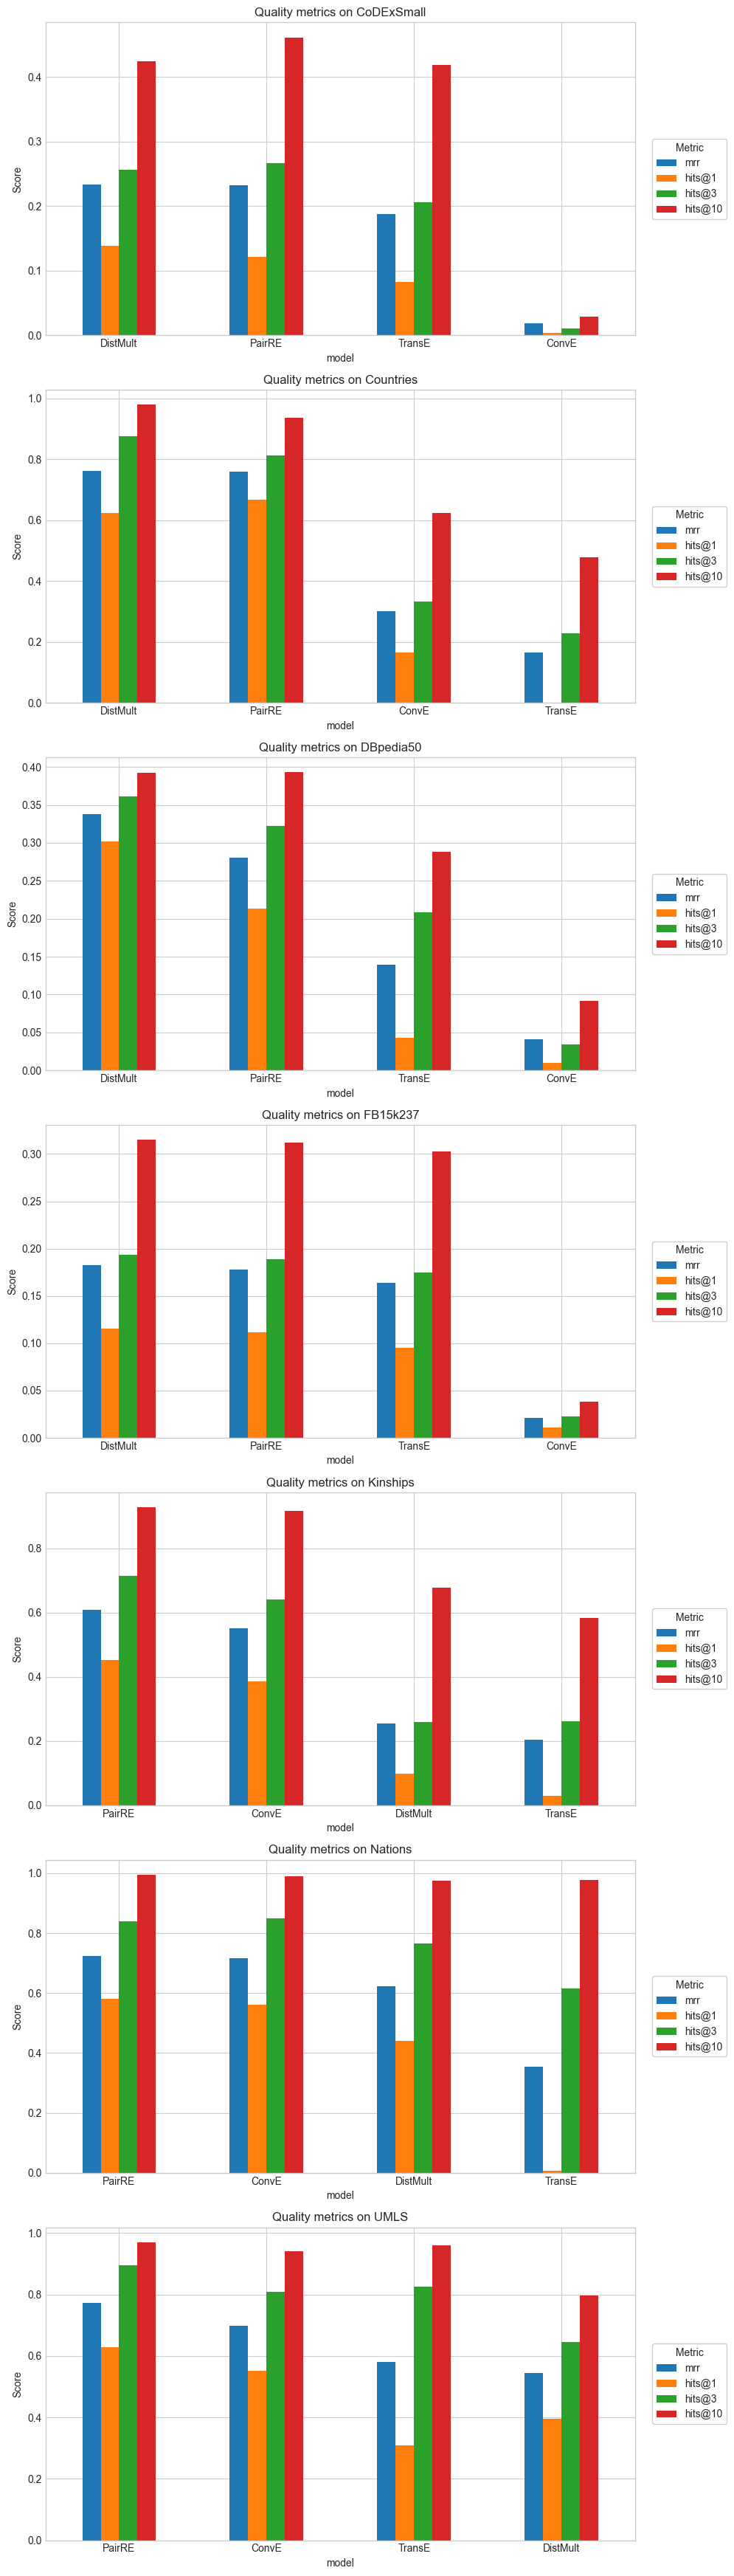

In [12]:
metric_columns = ['mrr', 'hits@1', 'hits@3', 'hits@10']
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 5 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    subset = results.loc[results['dataset'] == dataset_name].set_index('model')[metric_columns]
    subset.plot(kind='bar', ax=ax, rot=0, title=f'Quality metrics on {dataset_name}')
    ax.set_ylabel('Score')
    ax.legend(
        title='Metric',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        facecolor='white',
        framealpha=0.95,
    )

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

## Efficiency comparison

The next plots compare training time and parameter count for each dataset.


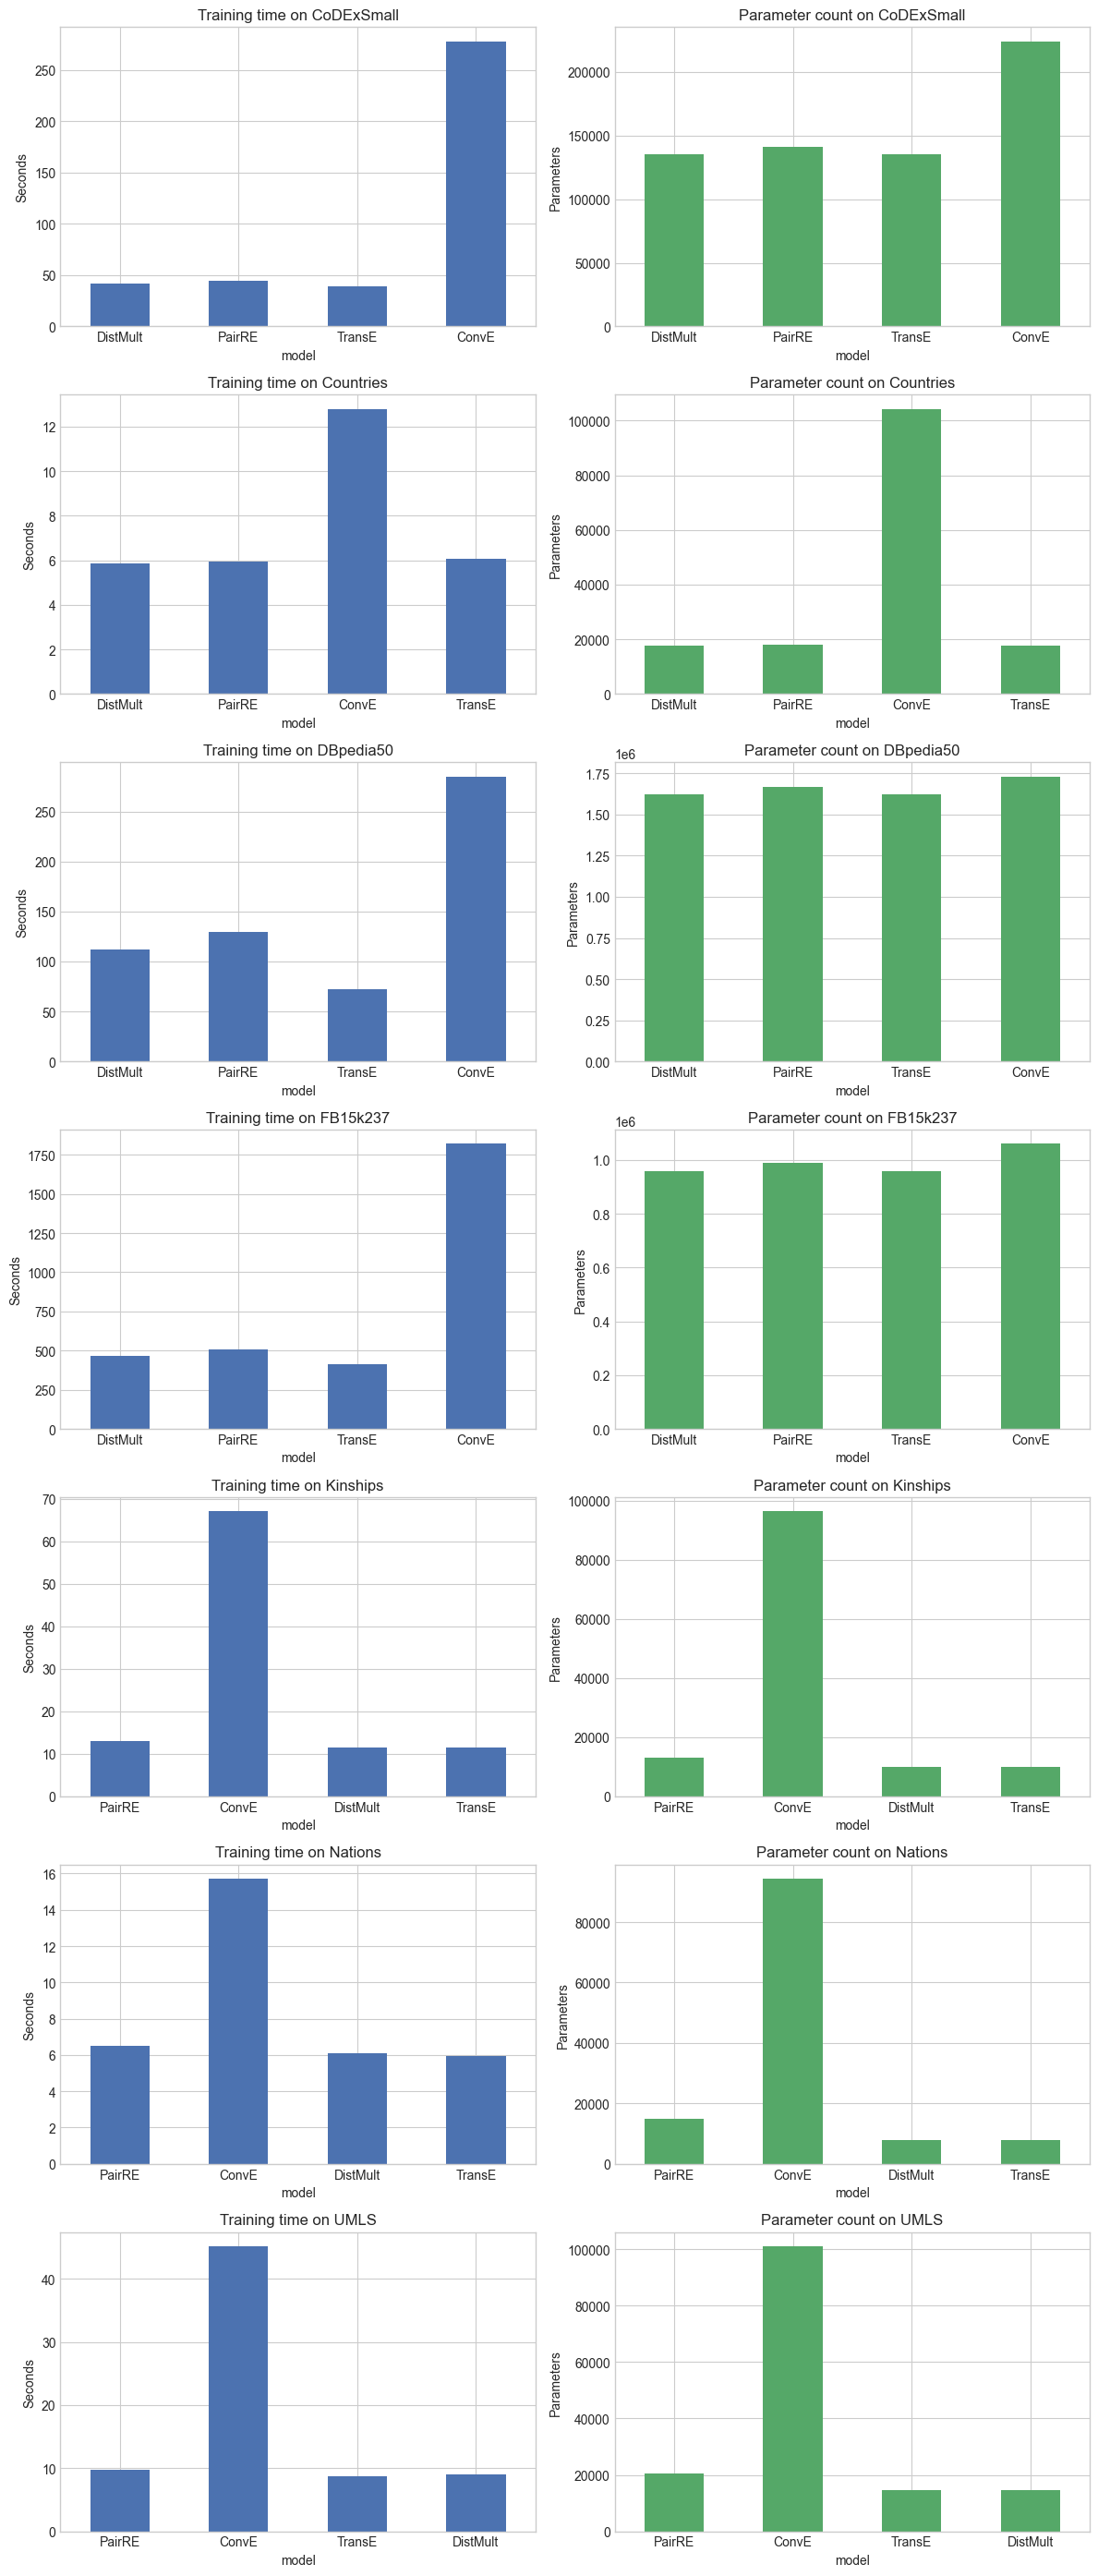

In [13]:
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    subset = results.loc[results['dataset'] == dataset_name]

    subset.plot(
        x='model',
        y='train_seconds',
        kind='bar',
        legend=False,
        ax=axes[row_index, 0],
        color='#4C72B0',
        rot=0,
        title=f'Training time on {dataset_name}',
    )
    axes[row_index, 0].set_ylabel('Seconds')

    subset.plot(
        x='model',
        y='parameter_count',
        kind='bar',
        legend=False,
        ax=axes[row_index, 1],
        color='#55A868',
        rot=0,
        title=f'Parameter count on {dataset_name}',
    )
    axes[row_index, 1].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

## Training curves

These curves give a simple sanity check that the models trained normally under the shared epoch budget.


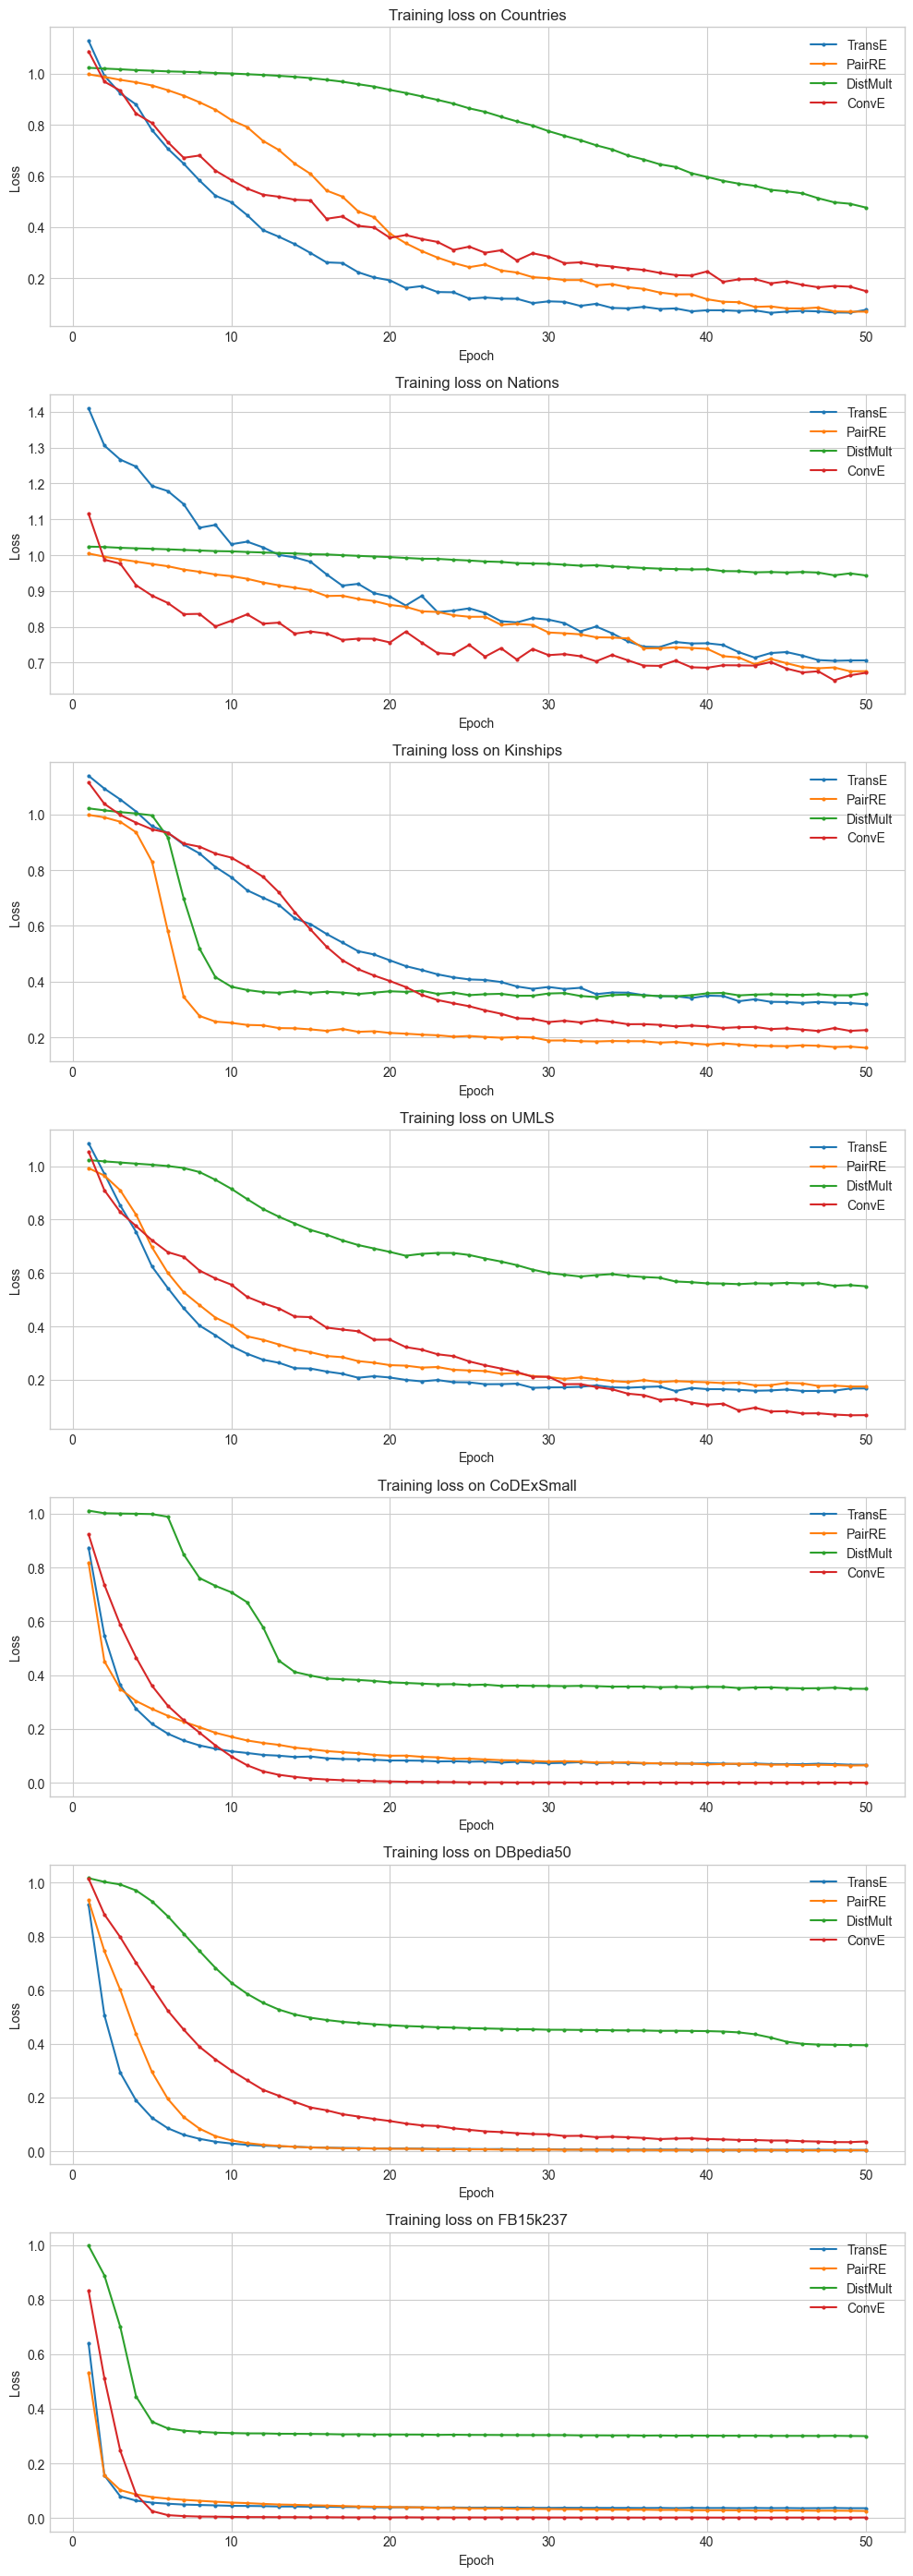

In [14]:
datasets = list(losses.keys())
fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    for model_name, loss_values in losses[dataset_name].items():
        epochs = range(1, len(loss_values) + 1)
        ax.plot(epochs, loss_values, marker='o', markersize=2, linewidth=1.5, label=model_name)
    ax.set_title(f'Training loss on {dataset_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## Model selection rationale

The final recommendation is based mainly on MRR, then checked against training time and parameter count.


In [15]:
best_per_dataset = (
    results.sort_values(['dataset', 'mrr', 'hits@10'], ascending=[True, False, False])
    .groupby('dataset', as_index=False)
    .first()
)

overall_best = summary_by_model.iloc[0]

lines = [
    '### Recommendation',
    '',
    f"For the selected benchmark mode, the strongest overall model is `{overall_best['model']}`.",
    '',
    f"- It has the best average MRR across the evaluated datasets: **{overall_best['mean_mrr']:.4f}**.",
    f"- Its average training time is **{overall_best['mean_train_seconds']:.2f} seconds**.",
    f"- Its average parameter count is **{int(round(overall_best['mean_parameter_count']))}**.",
    '',
    '### Best model by dataset',
    '',
]

for _, row in best_per_dataset.iterrows():
    lines.append(
        f"- `{row['dataset']}`: `{row['model']}` was best with MRR **{row['mrr']:.4f}**, "
        f"training time **{row['train_seconds']:.2f} s**, and **{int(row['parameter_count'])}** parameters."
    )

lines.extend([
    '',
    '### Short discussion',
    '',
    f"- `{overall_best['model']}` is the best final choice because it is strongest on average, not just on one dataset.",
    '- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.',
    '- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.',
])

display(Markdown('\n'.join(lines)))

### Recommendation

For the selected benchmark mode, the strongest overall model is `PairRE`.

- It has the best average MRR across the evaluated datasets: **0.5081**.
- Its average training time is **102.47 seconds**.
- Its average parameter count is **408859**.

### Best model by dataset

- `CoDExSmall`: `DistMult` was best with MRR **0.2335**, training time **41.95 s**, and **135552** parameters.
- `Countries`: `DistMult` was best with MRR **0.7622**, training time **5.85 s**, and **17600** parameters.
- `DBpedia50`: `DistMult` was best with MRR **0.3376**, training time **112.07 s**, and **1620864** parameters.
- `FB15k237`: `DistMult` was best with MRR **0.1825**, training time **467.58 s**, and **958656** parameters.
- `Kinships`: `PairRE` was best with MRR **0.6094**, training time **12.91 s**, and **13056** parameters.
- `Nations`: `PairRE` was best with MRR **0.7245**, training time **6.50 s**, and **14976** parameters.
- `UMLS`: `PairRE` was best with MRR **0.7718**, training time **9.73 s**, and **20416** parameters.

### Short discussion

- `PairRE` is the best final choice because it is strongest on average, not just on one dataset.
- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.
- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.

## Checked-in complete results

The seven-dataset benchmark is checked in under `results/complete/`; the table below summarizes those saved results and can still be inspected even if you switch `BENCHMARK_MODE` to `minimal` for a faster rerun.


In [16]:
complete_results_path = 'results/complete/benchmark_results.csv'
complete_results = pd.read_csv(complete_results_path)

complete_summary = (
    complete_results.groupby('model', as_index=False)
    .agg(
        mean_train_seconds=('train_seconds', 'mean'),
        mean_parameter_count=('parameter_count', 'mean'),
        mean_mrr=('mrr', 'mean'),
        mean_hits_at_1=('hits@1', 'mean'),
        mean_hits_at_3=('hits@3', 'mean'),
        mean_hits_at_10=('hits@10', 'mean'),
    )
    .sort_values('mean_mrr', ascending=False)
    .reset_index(drop=True)
)

complete_summary.round(4)


,model,mean_train_seconds,mean_parameter_count,mean_mrr,mean_hits_at_1,mean_hits_at_3,mean_hits_at_10
0,PairRE,102.4735,408859.4286,0.5081,0.3964,0.5768,0.7139
1,DistMult,93.4537,394998.8571,0.4199,0.3024,0.4796,0.6514
2,ConvE,360.5669,487356.1429,0.3355,0.2416,0.3854,0.5188
3,TransE,79.9315,394998.8571,0.2568,0.0811,0.3600,0.5729


## Conclusion

This notebook now supports both:

- a `minimal` benchmark for a fast, compact submission
- a `complete` benchmark with larger datasets and longer training times for a stronger comparison

Both modes satisfy the main case study requirements: fixed evaluation protocol, multiple KGE models, quality metrics, efficiency discussion, and an explicit model choice.
